# 01 - EDA & Stable Window Derivation

Profiling pass over the analytics star schema: order volume over time, null-timestamp
patterns by order status, category/state distributions, and delivery-days distribution.
Derives the "stable window" used consistently in this notebook's own trend commentary and
reused verbatim by the Phase 6 forecast (MASTER_DOC section 14) - never re-derived, never
assumed.

In [1]:
import sys

sys.path.insert(0, "..")  # repo root, so `src` is importable regardless of kernel cwd

import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import text

from src.utils import get_engine

engine = get_engine()
pd.set_option("display.max_rows", 30)

## Order volume over time (all placed orders)

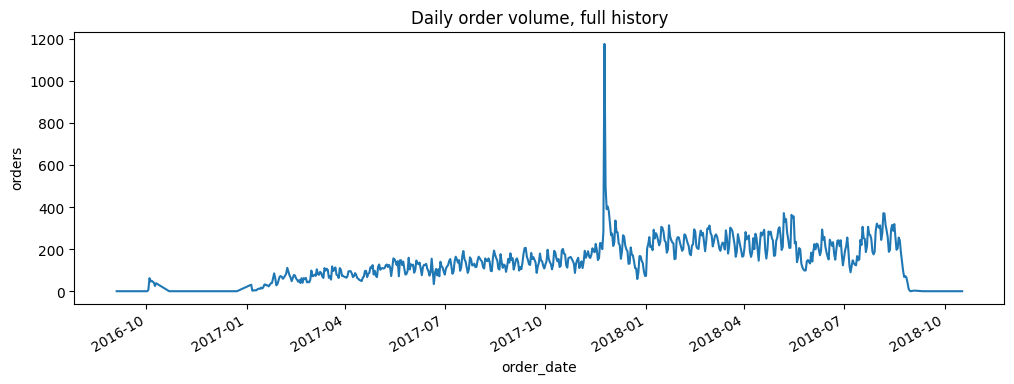

In [2]:
daily_orders = pd.read_sql(
    text("""
        SELECT order_purchase_timestamp::date AS order_date, COUNT(*) AS orders
        FROM analytics.fact_orders
        GROUP BY 1
        ORDER BY 1
    """),
    engine,
    parse_dates=["order_date"],
).set_index("order_date")["orders"]

fig, ax = plt.subplots(figsize=(12, 4))
daily_orders.plot(ax=ax)
ax.set_title("Daily order volume, full history")
ax.set_ylabel("orders")
plt.show()

The chart shows two problem regions: a sparse, gappy ramp from late August through
December 2016 (isolated single-digit days, one anomalous 283-order week, then long gaps
with zero orders), and a collapsing tail in late August-October 2018 where volume decays
from ~250/day down to a trickle of 1/day. Both are excluded from the stable window below -
not assumed, derived from the data actually shown here.

In [3]:
print("First 15 days with any orders:")
print(daily_orders[daily_orders > 0].head(15))
print()
print("Last 20 days with any orders:")
print(daily_orders[daily_orders > 0].tail(20))

First 15 days with any orders:
order_date
2016-09-04     1
2016-09-05     1
2016-09-13     1
2016-09-15     1
2016-10-02     1
2016-10-03     8
2016-10-04    63
2016-10-05    47
2016-10-06    51
2016-10-07    46
2016-10-08    42
2016-10-09    26
2016-10-10    39
2016-10-22     1
2016-12-23     1
Name: orders, dtype: int64

Last 20 days with any orders:
order_date
2018-08-27    67
2018-08-28    44
2018-08-29    14
2018-08-30     4
2018-08-31     1
2018-09-03     4
2018-09-06     3
2018-09-10     1
2018-09-11     1
2018-09-12     1
2018-09-13     1
2018-09-17     1
2018-09-20     1
2018-09-25     1
2018-09-26     1
2018-09-29     1
2018-10-01     1
2018-10-03     1
2018-10-16     1
2018-10-17     1
Name: orders, dtype: int64


**Derivation of the stable window:**
- Start: the 2016 ramp has real gap days (zero orders on multiple calendar days) through
  early January 2017 - including 2017-01-01 through 01-04 (New Year's holiday, zero
  orders). The first day starting a run with **no** gap days afterward is **2017-01-05**.
- End: daily volume decays continuously from 2018-08-23 onward (144 -> 99 -> 69 -> ... -> 1),
  clearly a data-collection cutoff, not a real demand drop. The last day of materially full
  volume is **2018-08-22**.

Verified below: zero gap days in `[2017-01-05, 2018-08-22]`, confirmed against a full
calendar-day count, not just eyeballed from the chart.

In [4]:
STABLE_WINDOW_START = "2017-01-05"
STABLE_WINDOW_END = "2018-08-22"

gap_check = pd.read_sql(
    text(f"""
        SELECT gs::date AS calendar_day
        FROM generate_series('{STABLE_WINDOW_START}'::date, '{STABLE_WINDOW_END}'::date, '1 day'::interval) gs
        LEFT JOIN (SELECT DISTINCT order_purchase_timestamp::date AS d FROM analytics.fact_orders) o
          ON gs::date = o.d
        WHERE o.d IS NULL
    """),
    engine,
)
assert len(gap_check) == 0, f"gap days found inside stable window: {gap_check}"
print(f"Stable window {STABLE_WINDOW_START} to {STABLE_WINDOW_END}: 0 gap days confirmed.")
print(f"This exact window is reused by notebooks/04_demand_forecast.ipynb (MASTER_DOC section 14).")

Stable window 2017-01-05 to 2018-08-22: 0 gap days confirmed.
This exact window is reused by notebooks/04_demand_forecast.ipynb (MASTER_DOC section 14).


## Null timestamps by order status

In [5]:
null_by_status = pd.read_sql(
    text("""
        SELECT
            order_status,
            COUNT(*) AS orders,
            COUNT(*) FILTER (WHERE order_approved_at IS NULL) AS null_approved_at,
            COUNT(*) FILTER (WHERE order_delivered_carrier_date IS NULL) AS null_delivered_carrier,
            COUNT(*) FILTER (WHERE order_delivered_customer_date IS NULL) AS null_delivered_customer
        FROM analytics.fact_orders
        GROUP BY order_status
        ORDER BY orders DESC
    """),
    engine,
)
null_by_status

,order_status,orders,null_approved_at,null_delivered_carrier,null_delivered_customer
0,delivered,96478,14,2,8
1,shipped,1107,0,0,1107
2,canceled,625,141,550,619
3,unavailable,609,0,609,609
4,invoiced,314,0,314,314
5,processing,301,0,301,301
6,created,5,5,5,5
7,approved,2,0,2,2


Null delivery timestamps concentrate exactly where expected: non-delivered statuses
(shipped, canceled, unavailable, invoiced, processing, created, approved) account for
essentially all `null_delivered_customer` rows - not a data quality problem, a consequence
of order lifecycle stage.

## Category distribution (by order-item count)

In [6]:
category_counts = pd.read_sql(
    text("""
        SELECT COALESCE(p.product_category_name_english, 'unknown') AS category, COUNT(*) AS items
        FROM analytics.fact_order_items oi
        JOIN analytics.dim_products p USING (product_id)
        GROUP BY 1
        ORDER BY items DESC
        LIMIT 15
    """),
    engine,
)
category_counts

,category,items
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827
5,housewares,6964
6,watches_gifts,5991
7,telephony,4545
8,garden_tools,4347
9,auto,4235


## State distribution (by customer count)

In [7]:
state_counts = pd.read_sql(
    text("""
        SELECT customer_state, COUNT(DISTINCT customer_unique_id) AS customers
        FROM analytics.dim_customers
        GROUP BY 1
        ORDER BY customers DESC
        LIMIT 10
    """),
    engine,
)
state_counts

,customer_state,customers
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882
5,SC,3534
6,BA,3277
7,DF,2075
8,ES,1964
9,GO,1952


## Delivery-days distribution (delivered orders only)

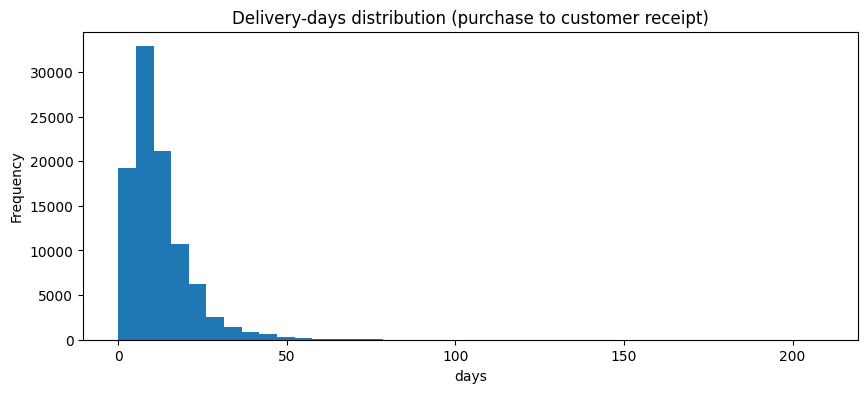

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64


In [8]:
delivery_days = pd.read_sql(
    text("""
        SELECT delivery_days
        FROM analytics.fact_orders
        WHERE order_status = 'delivered' AND delivery_days IS NOT NULL
    """),
    engine,
)["delivery_days"]

fig, ax = plt.subplots(figsize=(10, 4))
delivery_days.plot(kind="hist", bins=40, ax=ax)
ax.set_title("Delivery-days distribution (purchase to customer receipt)")
ax.set_xlabel("days")
plt.show()

print(delivery_days.describe())

## Data caveats (feeds README limitations section)

- **Stable window**: `2017-01-05` to `2018-08-22`. Trend/growth commentary and the Phase 6
  forecast both use this window; the sparse 2016 ramp and the 2018-08-23-onward collection
  cutoff are excluded, not smoothed over.
- **Delivery timestamps**: null exactly where the order hasn't reached that lifecycle stage
  yet (non-delivered statuses) - expected, not missing data.
- **Temporal anomalies** (quantified in Phase 2/3/4 validation, not re-derived here): 1,359
  orders show `delivered_carrier_date < approved_at`, 23 show
  `delivered_customer_date < delivered_carrier_date`, 6 canceled orders carry a delivery
  date. Left as-is in the source; noted for any delivery-time analysis.
- **Uncategorized products**: 610 products have no category in source (`product_category_name`
  null) - surfaced as `'unknown'` above rather than silently dropped.
- **Revenue definition**: item price + freight, delivered orders, reconciled against payments
  (303 of 99,441 orders show a >0.01 item-vs-payment mismatch - quantified in
  `sql/03_analysis/16_items_vs_payments_reconciliation.sql`, not treated as an error).